# Training Against a Perfect Opponent (Minimax)

So far the agent has trained against a random opponent, which rarely punishes mistakes. What happens if it
trains against an opponent that **never** makes one? The **Minimax** algorithm plays tic-tac-toe perfectly:
it never loses.

## The Minimax Algorithm

Minimax searches the complete game tree. It assumes that the player to move maximizes the score and the
opponent minimizes it, and scores each final position as win (+10), loss (−10) or draw (0). It is explained
step by step in [`02_minimax/MINIMAX_ALGORITHM.md`](../../02_minimax/MINIMAX_ALGORITHM.md).

`MinimaxAgent` (`core/agents/minimax_agent.py`) implements it, with two differences from `02_minimax`:

- It **picks at random among equally good moves**, so the games it plays are more varied.
- It prefers **faster wins and slower losses** (the score is adjusted by the search depth).

## Expected Training Outcomes

| Metric | Expected | Reason |
|--------|----------|--------|
| **Win rate** | 0% | Minimax is unbeatable |
| **Loss rate** | Should decrease | The agent learns to avoid losing lines |
| **Draw rate** | Should increase | Draw is the best possible result against perfect play |

## Setup

The reusable code lives in the `core` package, one folder up (`04_qlearning/core/`). We add that folder
to Python's import path so that `from core... import ...` works from this notebook. A fixed random seed
makes the results reproducible.

In [1]:
import sys
import random
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
random.seed(42)

## Minimax Agent Demonstration

First, let's check that Minimax never loses against a random opponent.

In [2]:
from core.agents.minimax_agent import MinimaxAgent
from core.agents.random_agent import RandomAgent
from core.training import evaluate_agent

minimax_vs_random = evaluate_agent(MinimaxAgent('O'), RandomAgent('X'), n_games=200)
print(f"Minimax vs Random: win {minimax_vs_random['win_rate']:.1%} | loss {minimax_vs_random['loss_rate']:.1%} | "
      f"draw {minimax_vs_random['draw_rate']:.1%}")

Minimax vs Random: win 84.5% | loss 0.0% | draw 15.5%


## Training Function

The agent (X) plays against Minimax (O), and the starter is chosen at random. We record the result rates
every 500 episodes. These rates include exploration moves.

In [3]:
from core.environment import TicTacToeEnvironment
from core.agents.q_learning_agent import QLearningAgent
from core.training import play_game


def train_vs_minimax(n_episodes: int = 10000, epsilon_start: float = 1.0, epsilon_end: float = 0.05,
                     epsilon_decay: float = 0.9995, eval_every: int = 500) -> tuple[QLearningAgent, dict]:
    agent = QLearningAgent(symbol='X', learning_rate=0.1, discount_factor=0.9, epsilon=epsilon_start)
    minimax = MinimaxAgent(symbol='O')
    env = TicTacToeEnvironment()

    history = {'wins': [], 'losses': [], 'draws': [], 'epsilon': []}
    results = {'X': 0, 'O': 0, 'draw': 0}
    epsilon = epsilon_start

    for episode in range(1, n_episodes + 1):
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        agent.set_epsilon(epsilon)

        results[play_game(agent, minimax, env, x_starts=random.choice([True, False]))] += 1

        if episode % eval_every == 0:
            history['wins'].append(results['X'] / eval_every)
            history['losses'].append(results['O'] / eval_every)
            history['draws'].append(results['draw'] / eval_every)
            history['epsilon'].append(epsilon)
            print(f"Episode {episode}: loss {history['losses'][-1]:.2f} | draw {history['draws'][-1]:.2f} | "
                  f"ε={epsilon:.3f}")
            results = {'X': 0, 'O': 0, 'draw': 0}

    return agent, history

## Training the Agent

In [4]:
agent, history = train_vs_minimax()

Episode 500: loss 0.87 | draw 0.13 | ε=0.779


Episode 1000: loss 0.89 | draw 0.11 | ε=0.606


Episode 1500: loss 0.82 | draw 0.18 | ε=0.472


Episode 2000: loss 0.72 | draw 0.28 | ε=0.368


Episode 2500: loss 0.65 | draw 0.35 | ε=0.286


...

Episode 8000: loss 0.10 | draw 0.90 | ε=0.050


Episode 8500: loss 0.08 | draw 0.92 | ε=0.050


Episode 9000: loss 0.09 | draw 0.91 | ε=0.050


Episode 9500: loss 0.08 | draw 0.92 | ε=0.050


Episode 10000: loss 0.09 | draw 0.91 | ε=0.050


## Training Progress Visualization

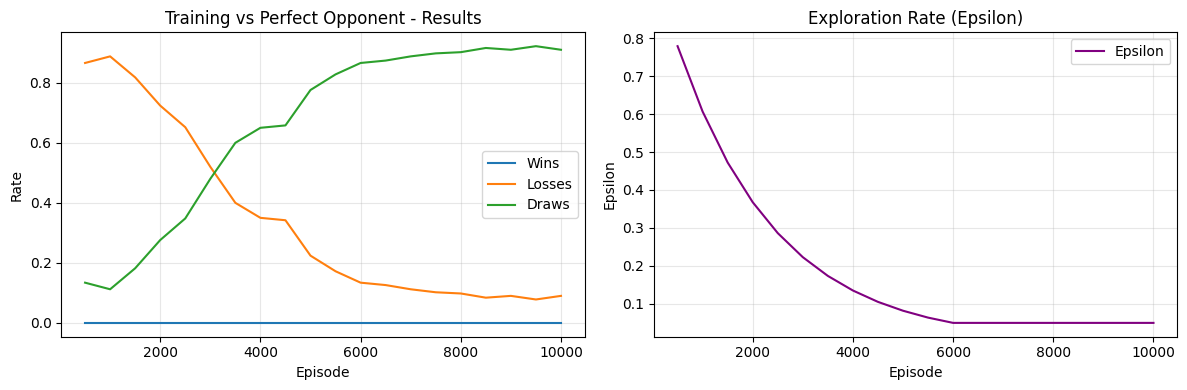

In [5]:
from core.training import plot_training_history

plot_training_history(history, eval_every=500, title='Training vs Perfect Opponent')

## Evaluation Against Minimax

The training curves include exploration. Without it, how often does the agent still lose?

In [6]:
results_vs_minimax = evaluate_agent(agent, MinimaxAgent('O'), n_games=300)
print(f"vs Minimax: loss {results_vs_minimax['loss_rate']:.1%} | draw {results_vs_minimax['draw_rate']:.1%}")

vs Minimax: loss 0.0% | draw 100.0%


Without exploration, the agent **never loses** against Minimax: it has learned to draw. The losses during
training (still around 9% at the end) must therefore come from the 5% of exploration moves. Against a
perfect opponent, a single bad move is enough to lose.

## Evaluation Against Random Opponent

How does this agent do against an opponent that plays very differently from its teacher?

In [7]:
results_vs_random = evaluate_agent(agent, RandomAgent('O'), n_games=1000)
print(f"vs Random: win {results_vs_random['win_rate']:.1%} | loss {results_vs_random['loss_rate']:.1%} | "
      f"draw {results_vs_random['draw_rate']:.1%}")
print(f"Q-table: {agent.get_stats()['unique_states']} states")

vs Random: win 50.2% | loss 34.0% | draw 15.8%
Q-table: 727 states


## Key Insights

Against a random opponent, the same agent loses **34%** of the games. That is much worse than the agent
trained against Random in notebook 02 (2.3%). Its Q-table has only 727 states, compared with about 4,400
in notebook 01.

The reason is **coverage**. Minimax always steers the game towards a small set of positions, so the agent
only learns what to do there. A random opponent quickly leads it into positions it has never seen, where
every Q-value is 0 and it plays at random.

Training against Minimax teaches the agent to avoid the mistakes Minimax punishes, in the positions
Minimax reaches. It does **not** teach:

- what to do in the many positions a perfect opponent never produces;
- how to exploit mistakes, because Minimax makes none (the agent never won a training game).

A good teacher must be both strong **and** varied. In the next notebook, the agent's opponent is another
learner.